# 04 - Visualization

Final publication-quality plots for the Reverse Turing Test analysis.

Outputs saved to `outputs/plots/`:
- `umap_clustering.html` — interactive UMAP (K-Means + DBSCAN)
- `wordclouds.png` — word clouds per model
- `frequency_by_model.html` — top words per model, T comparison
- `locked_vs_distributed.png` — entropy / diversity summary

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.cluster import KMeans, DBSCAN
from scipy.stats import entropy as scipy_entropy
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

BASE     = Path("..")
DATA_DIR = BASE / "data/processed"
OUT_DIR  = BASE / "outputs/plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

all_data = pd.read_csv(DATA_DIR / "all_data.csv")
all_data["word"] = (
    all_data["word"]
    .str.replace(r"\*+", "", regex=True)
    .str.strip()
    .str.replace("\u2019", "'")
    .str.lower()
)
all_data = all_data.dropna(subset=["word"])

umap_df = pd.read_csv(DATA_DIR / "umap/umap_st_plain.csv")
word_totals = all_data.groupby("word").size().rename("total")
umap_df = umap_df.merge(word_totals, on="word", how="left")

SHORT = {
    "claude-sonnet-4-6": "Claude",
    "deepseek-chat":     "DeepSeek",
    "gemini-2.5-flash":  "Gemini",
    "gpt-4o":            "GPT-4o",
    "grok-3":            "Grok",
    "llama3.2:3b":       "Llama",
    "qwen2.5:14b":       "Qwen",
}
SHORT_INV = {v: k for k, v in SHORT.items()}
umap_df["model_short"] = umap_df["model"].map(SHORT)

MODEL_COLORS = {
    "Claude":   "#1f77b4",
    "DeepSeek": "#ff7f0e",
    "Gemini":   "#2ca02c",
    "GPT-4o":   "#d62728",
    "Grok":     "#9467bd",
    "Llama":    "#8c564b",
    "Qwen":     "#e377c2",
}

print(f"{len(all_data)} responses | {len(umap_df)} unique words in UMAP")
umap_df.head()

1397 responses | 71 unique words in UMAP


,x,y,word,model,total,model_short
0,-4.799034,6.728733,tired,claude-sonnet-4-6,177,Claude
1,-3.830834,4.742749,honestly,claude-sonnet-4-6,7,Claude
2,-0.797066,3.985438,ugh,claude-sonnet-4-6,16,Claude
3,-1.031205,3.795961,oops,deepseek-chat,258,DeepSeek
4,-7.634832,6.268178,empathy,gpt-4o,214,GPT-4o


## 1 - UMAP Scatter: K-Means & DBSCAN

Three panels side by side:
- **Left**: colored by dominant model (reference)
- **Middle**: K-Means k=3, symbol = dominant model
- **Right**: DBSCAN eps=0.8, symbol = dominant model

Marker size proportional to word frequency. Hover for word, model, count, cluster.

In [2]:
X_2d = umap_df[["x", "y"]].values

# K-Means k=3
km = KMeans(n_clusters=3, random_state=42, n_init=20)
umap_df["km_label"] = km.fit_predict(X_2d)

km_names = {}
for label in sorted(umap_df["km_label"].unique()):
    top = umap_df[umap_df["km_label"] == label].nlargest(3, "total")["word"].tolist()
    km_names[label] = f"KM-{label}: {', '.join(top)}"
umap_df["km_name"] = umap_df["km_label"].map(km_names)

# DBSCAN eps=0.8
db = DBSCAN(eps=0.8, min_samples=2)
umap_df["db_label"] = db.fit_predict(X_2d)

db_names = {}
for label in sorted(umap_df["db_label"].unique()):
    if label == -1:
        db_names[label] = "Noise"
    else:
        top = umap_df[umap_df["db_label"] == label].nlargest(3, "total")["word"].tolist()
        db_names[label] = f"DB-{label}: {', '.join(top)}"
umap_df["db_name"] = umap_df["db_label"].map(db_names)

print("K-Means clusters:")
for k, v in km_names.items():
    words = umap_df[umap_df["km_label"] == k]["word"].tolist()
    print(f"  {v}  =>  {words}")
print("\nDBSCAN clusters:")
for k, v in db_names.items():
    words = umap_df[umap_df["db_label"] == k]["word"].tolist()
    print(f"  {v}  =>  {words}")


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\morit\miniconda3\envs\reverse_turing\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\morit\miniconda3\envs\reverse_turing\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\morit\miniconda3\envs\reverse_turing\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte


K-Means clusters:
  KM-0: empathy, understanding, emotions  =>  ['empathy', 'breathe', 'fumble', 'vulnerability', 'existential', 'sorrow', 'struggle', 'curiosity', 'grief', 'miserable', 'love', 'embrace', 'emotions', 'cry', 'happiness', 'hobbies', 'suffering', 'emotion', 'regret', 'understanding']
  KM-1: oops, hey, laughter  =>  ['ugh', 'oops', 'ouch', 'flawed', 'hope', 'no', 'alas', 'sonder', 'impossible', 'nope', 'inconsistent', 'fathom', 'incomplete', 'hmm', 'hello', 'sorry', 'humor', 'unlikely', 'hey', 'please', 'smile', 'laughter', 'laughed', 'sarcasm', 'laugh', 'lol', 'i', 'imperfections', "i'd"]
  KM-2: tired, honestly, feel  =>  ['tired', 'honestly', 'feel', 'felt', 'ache', 'flesh', 'touch', 'pain', 'imagine', 'exist', 'ponder', 'dream', 'ai', 'believe', 'human', 'banana', 'coffee', 'dreams', 'caffeine', 'sleep', 'fingerprints', 'imagination']

DBSCAN clusters:
  Noise  =>  ['unlikely']
  DB-0: empathy, understanding, tired  =>  ['tired', 'honestly', 'empathy', 'feel', 'felt',

In [3]:
SYMBOL_MAP = {
    "Claude":"circle", "DeepSeek":"square", "Gemini":"diamond",
    "GPT-4o":"cross",  "Grok":"x",          "Llama":"triangle-up", "Qwen":"star"
}
KM_COLORS = ["#e41a1c", "#377eb8", "#4daf4a"]
DB_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]
NOISE_CLR = "#aaaaaa"

def mksize(s):
    return (s.clip(upper=50) / 4 + 6).tolist()

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=["Colored by Model", "K-Means (k=3)", "DBSCAN (eps=0.8)"],
    horizontal_spacing=0.06
)

# Panel 1 - by model
for i, (ms, clr) in enumerate(MODEL_COLORS.items()):
    sub = umap_df[umap_df["model_short"] == ms]
    fig.add_trace(go.Scatter(
        x=sub["x"], y=sub["y"],
        mode="markers+text", name=ms,
        text=sub["word"], textposition="top center", textfont=dict(size=8),
        marker=dict(size=mksize(sub["total"]), color=clr, opacity=0.85),
        customdata=sub[["model_short", "total"]].values,
        hovertemplate="<b>%{text}</b><br>Model: %{customdata[0]}<br>Count: %{customdata[1]}<extra></extra>",
        legendgroup="model",
        legendgrouptitle_text="Model" if i == 0 else None,
    ), row=1, col=1)

# Panel 2 - K-Means
for i, (label, name) in enumerate(km_names.items()):
    sub = umap_df[umap_df["km_label"] == label]
    fig.add_trace(go.Scatter(
        x=sub["x"], y=sub["y"],
        mode="markers+text", name=name,
        text=sub["word"], textposition="top center", textfont=dict(size=8),
        marker=dict(
            size=mksize(sub["total"]),
            color=KM_COLORS[i],
            symbol=sub["model_short"].map(SYMBOL_MAP).tolist(),
            opacity=0.85,
        ),
        customdata=sub[["model_short", "total"]].values,
        hovertemplate=f"<b>%{{text}}</b><br>Model: %{{customdata[0]}}<br>Count: %{{customdata[1]}}<br>{name}<extra></extra>",
        legendgroup="kmeans",
        legendgrouptitle_text="K-Means" if i == 0 else None,
    ), row=1, col=2)

# Panel 3 - DBSCAN
db_order = [l for l in sorted(umap_df["db_label"].unique()) if l != -1] + [-1]
for i, label in enumerate(db_order):
    name = db_names[label]
    sub  = umap_df[umap_df["db_label"] == label]
    clr  = NOISE_CLR if label == -1 else DB_COLORS[i % len(DB_COLORS)]
    fig.add_trace(go.Scatter(
        x=sub["x"], y=sub["y"],
        mode="markers+text", name=name,
        text=sub["word"], textposition="top center", textfont=dict(size=8),
        marker=dict(
            size=mksize(sub["total"]),
            color=clr,
            symbol=sub["model_short"].map(SYMBOL_MAP).tolist(),
            opacity=0.4 if label == -1 else 0.85,
        ),
        customdata=sub[["model_short", "total"]].values,
        hovertemplate=f"<b>%{{text}}</b><br>Model: %{{customdata[0]}}<br>Count: %{{customdata[1]}}<br>{name}<extra></extra>",
        legendgroup="dbscan",
        legendgrouptitle_text="DBSCAN" if i == 0 else None,
    ), row=1, col=3)

fig.update_layout(
    title=dict(
        text="UMAP 2D Projection - ST plain (all-MiniLM-L6-v2)<br><sup>Size ~ word frequency | Symbol = dominant model</sup>",
        x=0.5
    ),
    height=650, width=1700,
    legend=dict(groupclick="toggleitem", tracegroupgap=15),
    template="plotly_white", font=dict(size=11),
)
fig.update_xaxes(title_text="UMAP-1")
fig.update_yaxes(title_text="UMAP-2", col=1)

out = OUT_DIR / "umap_clustering.html"
fig.write_html(str(out))
print(f"Saved -> {out}")
fig.show()


Saved -> ..\outputs\plots\umap_clustering.html


## 2 - Word Clouds per Model

Word size proportional to frequency (T=0.7 + T=1.0 combined).

Saved -> ..\outputs\plots\wordclouds.png


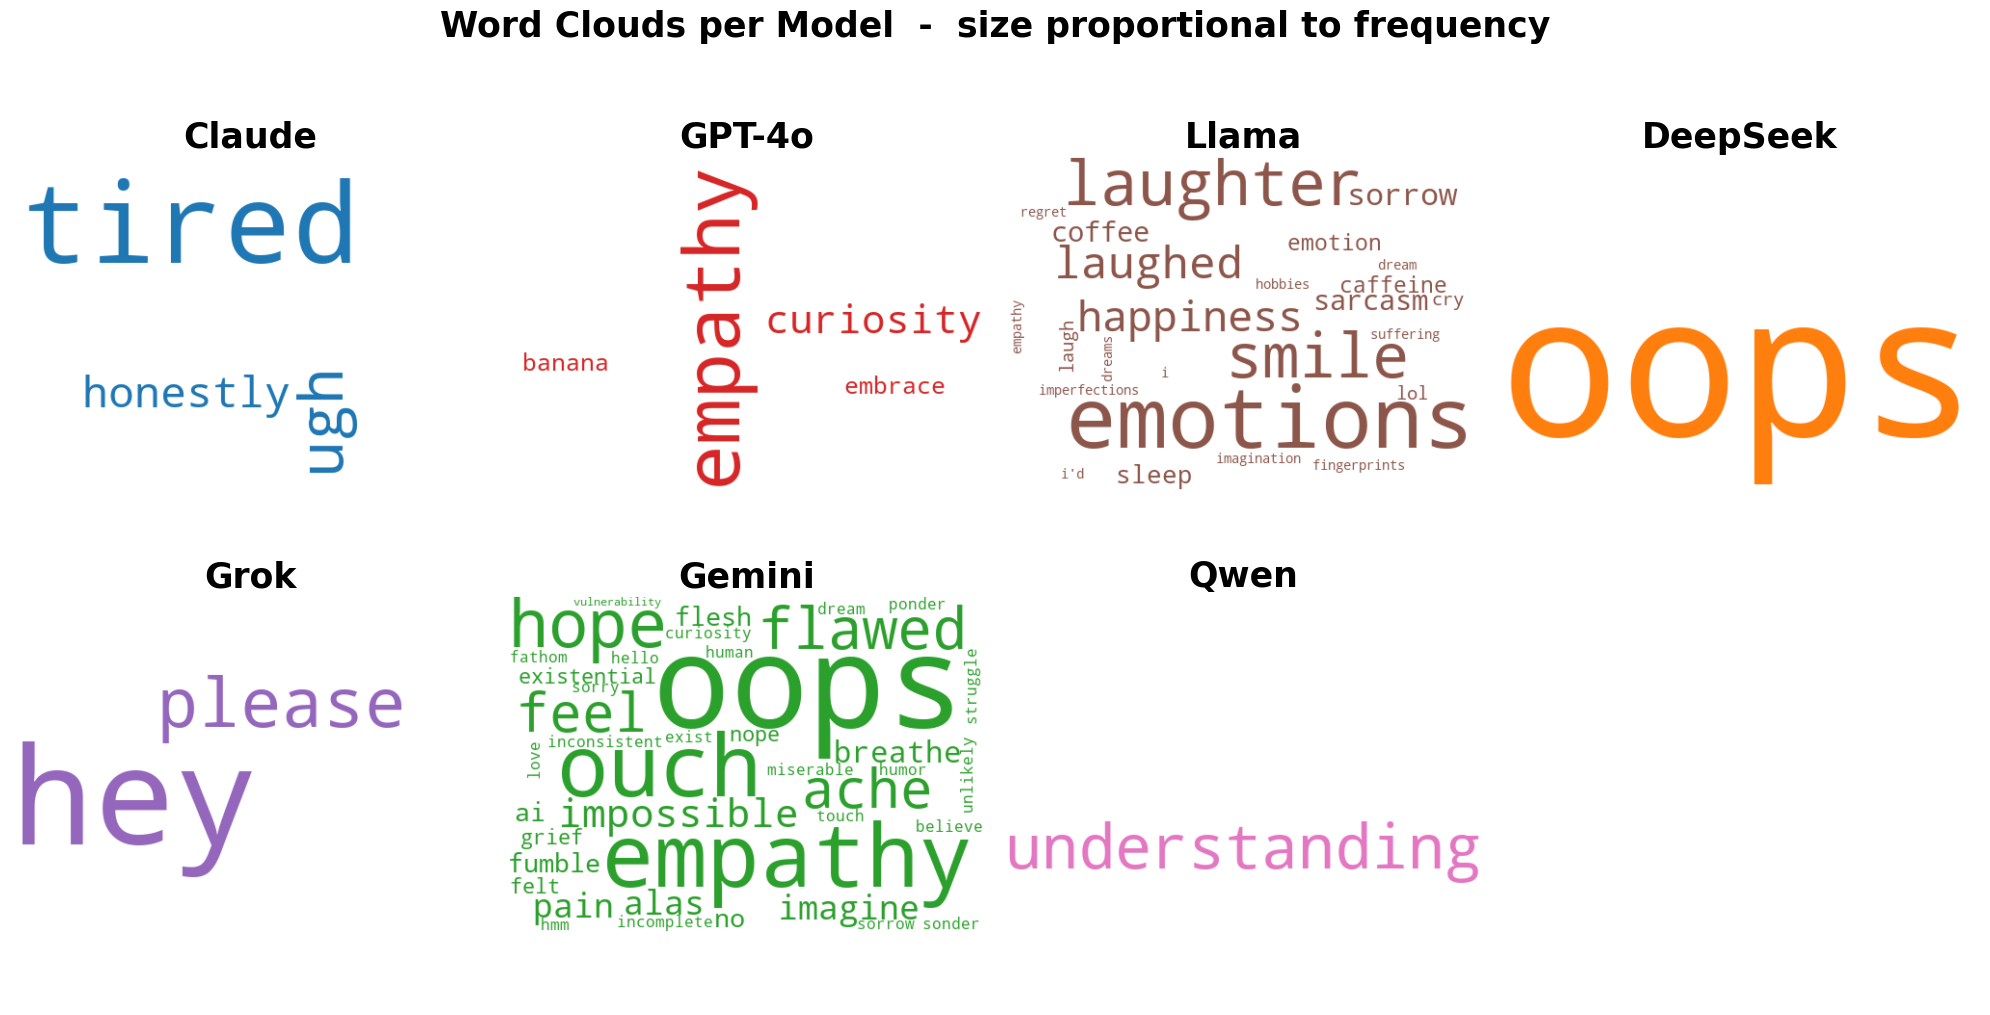

In [4]:
MODEL_ORDER = ["Claude", "GPT-4o", "Llama", "DeepSeek", "Grok", "Gemini", "Qwen"]

fig_wc, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ms in enumerate(MODEL_ORDER):
    mid   = SHORT_INV[ms]
    freq  = all_data[all_data["model"] == mid].groupby("word").size().to_dict()
    color = MODEL_COLORS[ms]
    wc = WordCloud(
        width=500, height=350,
        background_color="white",
        color_func=lambda *a, **kw: color,
        max_words=60,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(ms, fontsize=25, fontweight="bold")

axes[-1].axis("off")
fig_wc.suptitle("Word Clouds per Model  -  size proportional to frequency",
                fontsize=25, fontweight="bold", y=1.01)
fig_wc.tight_layout()

out = OUT_DIR / "wordclouds.png"
fig_wc.savefig(str(out), dpi=150, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


## 3 - Top Words per Model (Interactive)

Top 5 words per model, T=0.7 vs T=1.0 grouped bar.

In [5]:
TOP_N = 5

freq_data = (
    all_data.groupby(["model", "temperature", "word"])
    .size().reset_index(name="count")
)
top_words = (
    freq_data.groupby(["model", "word"])["count"].sum().reset_index()
    .sort_values("count", ascending=False)
    .groupby("model").head(TOP_N)
)
plot_data = freq_data.merge(top_words[["model", "word"]], on=["model", "word"])
plot_data["model_short"] = plot_data["model"].map(SHORT)
plot_data["temp_label"]  = plot_data["temperature"].map({0.7: "T=0.7", 1.0: "T=1.0"})

fig_freq = px.bar(
    plot_data,
    x="word", y="count",
    color="temp_label",
    barmode="group",
    facet_col="model_short",
    facet_col_wrap=4,
    color_discrete_map={"T=0.7": "#2196F3", "T=1.0": "#FF9800"},
    labels={"count": "Count", "word": "", "temp_label": "Temperature"},
    title=f"Top {TOP_N} Words per Model - T=0.7 vs T=1.0",
    height=600,
)
fig_freq.update_layout(template="plotly_white", font=dict(size=11))
fig_freq.update_xaxes(tickangle=30)
fig_freq.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

out = OUT_DIR / "frequency_by_model.html"
fig_freq.write_html(str(out))
print(f"Saved -> {out}")
fig_freq.show()


Saved -> ..\outputs\plots\frequency_by_model.html


## 4 - Locked vs Distributed Summary

Dominant word share, unique vocabulary, and entropy ordered from most locked to most distributed.

Saved -> ..\outputs\plots\locked_vs_distributed.png


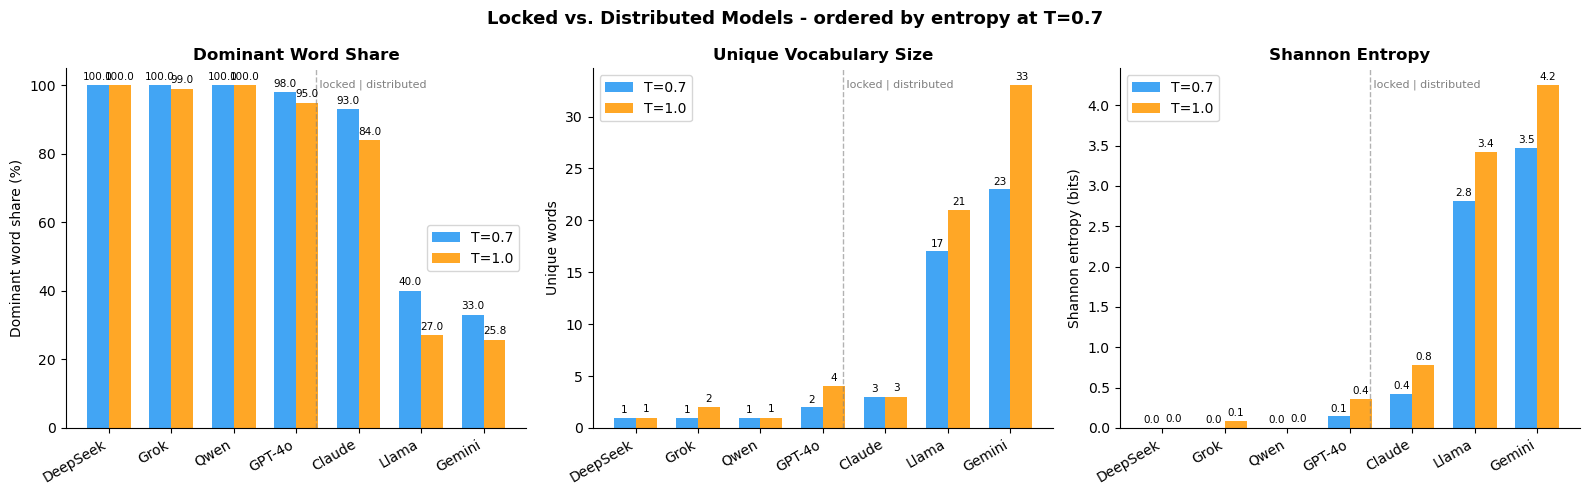


Summary (T=0.7, ordered by entropy):
               top_word  top_pct  n_unique  entropy
model                                              
DeepSeek           oops    100.0         1    0.000
Grok                hey    100.0         1    0.000
Qwen      understanding    100.0         1    0.000
GPT-4o          empathy     98.0         2    0.141
Claude            tired     93.0         3    0.426
Llama          emotions     40.0        17    2.816
Gemini             oops     33.0        23    3.472


In [6]:
summary_rows = []
for model_id, ms in SHORT.items():
    for temp in [0.7, 1.0]:
        sub    = all_data[(all_data["model"] == model_id) & (all_data["temperature"] == temp)]
        counts = sub["word"].value_counts()
        probs  = counts / counts.sum()
        if counts.empty:
            sub = all_data[
            (all_data["model"] == model_id)
            & np.isclose(all_data["temperature"].astype(float), temp)
            ]
            counts = sub["word"].value_counts()
            probs = counts / counts.sum() if not counts.empty else pd.Series(dtype=float)

        summary_rows.append(dict(
            model=ms,
            temperature=temp,
            top_word=counts.index[0] if not counts.empty else None,
            top_pct=(counts.iloc[0] / counts.sum() * 100) if not counts.empty else 0.0,
            n_unique=len(counts),
            entropy=scipy_entropy(probs, base=2) if not counts.empty else 0.0,
        ))
summary = pd.DataFrame(summary_rows)

order = (
    summary[summary["temperature"] == 0.7]
    .sort_values("entropy")["model"].tolist()
)

fig_sum, axes = plt.subplots(1, 3, figsize=(16, 5))
x, w = np.arange(len(order)), 0.35

for ax, metric, ylabel, title in zip(
    axes,
    ["top_pct", "n_unique", "entropy"],
    ["Dominant word share (%)", "Unique words", "Shannon entropy (bits)"],
    ["Dominant Word Share", "Unique Vocabulary Size", "Shannon Entropy"],
):
    for j, (temp, lbl, c) in enumerate([(0.7, "T=0.7", "#2196F3"), (1.0, "T=1.0", "#FF9800")]):
        vals = [
            summary[(summary["model"] == m) & (summary["temperature"] == temp)][metric].values[0]
            for m in order
        ]
        bars = ax.bar(x + j * w, vals, w, label=lbl, color=c, alpha=0.85)
        for bar, val in zip(bars, vals):
            fmt = f"{val:.1f}" if metric != "n_unique" else str(int(val))
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.01,
                    fmt, ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels(order, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    boundary = sum(
        1 for m in order
        if summary[(summary["model"] == m) & (summary["temperature"] == 0.7)]["entropy"].values[0] < 0.3
    )
    ax.axvline(boundary - 0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.text(boundary - 0.5, ax.get_ylim()[1] * 0.97,
            " locked | distributed", color="gray", fontsize=8, va="top")

fig_sum.suptitle("Locked vs. Distributed Models - ordered by entropy at T=0.7",
                 fontsize=13, fontweight="bold")
fig_sum.tight_layout()

out = OUT_DIR / "locked_vs_distributed.png"
fig_sum.savefig(str(out), dpi=150, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()

print("\nSummary (T=0.7, ordered by entropy):")
print(summary[summary["temperature"] == 0.7].set_index("model").loc[order]
      [["top_word", "top_pct", "n_unique", "entropy"]].round(3))
